<div style="background-color:rgb(100, 110, 220); padding:10px;">

## Day 4: Advanced Classification and Model Validation
- **Data Preprocessing**
  - **Pipelines**
    - Introduction to ML Pipelines
    - Automating preprocessing steps with Pipelines
- **Machine Learning Algorithms**
  - Advanced Classification (K-Nearest Neighbors)
- **Model Selection and Evaluation**
  - Precision_recall_curve, ROC AUC



### Dataset:  indian_airquality.csv
### libraries: pandas, scikit learn, matplotlib, and seaborn



# 1. Data Preprocessing: Pipelines

## Reminder of the data processing needed on this dataset:
0. Remove duplicates
1. Split the data
1'. Seprate the categorical and numeric data
### Based on EDA (visualisation, looking at statistical summary and domain knowledge) dealing with:
2. Missing Data  
3. Scale Features 
4. Remove Outliers 
5. Engineer Features -- drop unnecessary features, logarithmic feature, polynomial features
6. Encode categorical Data
7. Select Feature 

* Need to train and apply these to our **training set**
* Need to apply the same transformations to our **validation set/validation folds (via CV)**
* Need to apply the same transformations to our **new data/test set**
* This implies we need to save (and load) <span style="color:red">**several independant transformers**</span>. 

### <span style="color:teal">Messy, work-intensive and entails large potential for bugs and errors.</span>



## 1.1. Why Use Pipelines?

- **Automation**: Automate repetitive tasks and preprocessing steps.
- **Consistency**: Ensure that the same sequence of steps is applied during both training and testing.
- **Cleaner Code**: Organize and structure code better, making it easier to maintain and extend.
- **Data_leakage prevention**: Pipelines ensure that preprocessing steps are not influenced by test data, preventing data leakage.

### 1.2 Automating Preprocessing Steps with Pipelines

A typical pipeline in scikit-learn might include steps like scaling features, handling missing values, encoding categorical variables, and then applying a machine learning algorithm.

#### Example: Building a Simple Pipeline


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Lecture_data/India_airquality.csv')
# REMINDER: 1. Always drop duplicates first
df.drop_duplicates(inplace=True)
df

,stn_code,state,location,type,so2,no2,date,rainfall,high_level
0,NaN,Maharashtra,Navi Mumbai,Others,12.0,17.0,21/08/2008,69.776897,1
1,334,Gujarat,Vadodara,Industrial,24.0,48.0,02/03/2010,NaN,1
2,NaN,Karnataka,Hubli-Dharwad,Others,NaN,6.8,08/02/2007,79.575206,0
3,NaN,Chandigarh,Chandigarh,Others,NaN,11.0,08/05/2005,108.009090,0
4,598,Karnataka,Bangalore,Sensitive,9.0,19.0,18/02/2014,93.589798,0
...,...,...,...,...,...,...,...,...,...
27865,689,Odisha,Balasore,Residential,2.0,13.0,26/11/2013,NaN,1
27866,665,Himachal Pradesh,Sunder Nagar,Residential,2.0,8.0,07/03/2013,98.072063,0
27867,NaN,Andhra Pradesh,Visakhapatnam,Industrial,11.5,29.1,09/01/2006,79.776776,0
27868,NaN,Kerala,Trivandrum,Others,7.3,27.5,07/04/2008,101.609464,0


In [2]:
from sklearn.model_selection import train_test_split
# 2.  Identifying Target and Splitting Datase
X = df.drop(columns=['high_level', 'stn_code', 'date'])  # Dropping non-relevant and target columns
y = df['high_level']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [3]:
# 3. Data Types and Separating Categorical and Numerical Data
#print(X_train.dtypes)

# Separating categorical and numerical features
# We do this as we have different preprocessing steps for each type of data

categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [5]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
categorical_transformer

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [6]:
numeric_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [7]:
categorical_transformer

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


## FunctionTransformer

The `FunctionTransformer` is a versatile tool in the `sklearn.preprocessing` module that allows you to apply any custom function to your data within a pipeline. This can be particularly useful for data preprocessing tasks that are not covered by the built-in transformers in scikit-learn.


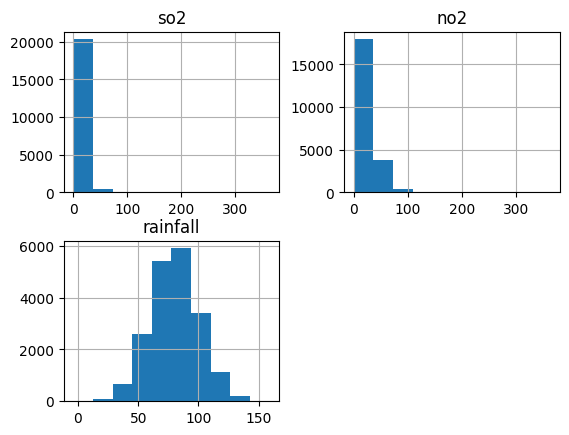

In [8]:
X_train[numerical_cols].hist();

In [9]:
# step 1: # Define a function to apply log transformation and handle zero values

from sklearn.preprocessing import FunctionTransformer
import numpy as np

def log_function(x):
    return np.log1p(x)  # np.log1p adds 1 to handle log(0)

# Step2: Create the transformer with our custom function
log_custom = FunctionTransformer(log_function, feature_names_out='one-to-one')

# Step3: Specify the columns that need the log transformation
log_transform_cols = ['so2', 'no2']


# Step 4: create a custom_pipe:
log_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('log_transform', log_custom)
])
log_transformer

,steps,"[('imputer', ...), ('log_transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,func,<function log...x7201d4e4a8e0>


#### Now lets put everything together

In [10]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, log_transform_cols),  # Log-transform specific columns
        ('num', numeric_transformer, numerical_cols.difference(log_transform_cols)),  # Other numerical columns
        ('cat', categorical_transformer, categorical_cols)  # Categorical columns
    ]
)

preprocessor

,transformers,"[('log', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [12]:
categorical_cols

Index(['state', 'location', 'type'], dtype='object')

In [11]:
numerical_cols

Index(['so2', 'no2', 'rainfall'], dtype='object')

In [11]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

###  Add the model to the pipeline for simplicity


In [12]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000))
])


In [13]:
lr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function log_function at 0x7f0f9a6b8dc0>))]),
                                                  ['so2', 'no2']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['rainfall'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['state', 'location', 'type'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring="accuracy")
print(f"CV accuracy: {acc.mean():.3f} ± {acc.std():.3f}")


CV accuracy: 0.766 ± 0.004


In [15]:
lr_pipeline.fit(X_train, y_train)
# Predict using the final pipeline
y_pred_lr = lr_pipeline.predict(X_test)


# 2. Machine Learning Algorithms: Advanced Classification

In this section, we will focus on  the K-Nearest Neighbors (KNN) algorithm, a simple yet powerful non-parametric classifier used for classification tasks.

**For more see [KNN Notes](../Dive_deeper/KNN.pdf)**


<div style="background-color:rgba(60, 179, 113, 0.3); padding:10px;">

## 2.1 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm that doesn’t assume any underlying distribution of the data.
works by:

1. Calculating the distance between the new data point and all training data points.
2. Selecting the top k closest neighbors.
3. Assigning the majority class among the neighbors to the new data point.

### Key Concepts:

#### Distance Metric:
KNN typically uses Euclidean distance:

$$
d(x, x') = \sqrt{\sum_{i=1}^{n} (x_i - x_i')^2}
$$

Where $ x $ and $ x' $ are two data points, and $ x_i $ and $ x_i' $ are the values of the $ i $-th feature for the two points.

Other distance metrics include Manhattan distance:

$$
d(x, x') = \sum_{i=1}^{n} |x_i - x_i'|
$$

#### k (Number of Neighbors):
The number of nearest neighbors considered for the classification.


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Define a pipeline with preprocessing and KNN classifier
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))  # 5 nearest neighbors
])

# Fit the pipeline to the training data
knn_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_pipeline.predict(X_test)


## 🔧 Hyperparameters in K-Nearest Neighbors (KNN)
In K-Nearest Neighbors (KNN), several hyperparameters influence how the model classifies data points. The main one is: `n_neighbors`

The value of k determines how many neighbors are considered for classifying each point. The choice of k balances bias and variance:

- **Low k**: Leads to more complex models with high variance, prone to overfitting.
- **High k**: Leads to simpler models with higher bias, prone to underfitting.


In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ks = [1, 3, 5, 7, 9, 11, 15]
rows = []

for k in ks:
    pipe_knn = Pipeline([
        ("pre", preprocessor),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    cv_acc = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring="accuracy")
    cv_f1  = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring="f1")  # binary; use 'f1_macro' if multiclass
    rows.append({
        "k": k,
        "cv_acc_mean": cv_acc.mean(), "cv_acc_std": cv_acc.std(),
        "cv_f1_mean":  cv_f1.mean(),  "cv_f1_std":  cv_f1.std()
    })

cv_table = pd.DataFrame(rows).sort_values(by=["cv_f1_mean","cv_acc_mean"], ascending=False)
print("KNN CV results (train-only):")
display(cv_table)


KNN CV results (train-only):


,k,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
4,9,0.760406,0.003925,0.759868,0.003333
3,7,0.759374,0.003628,0.759329,0.002491
6,15,0.758208,0.001704,0.756940,0.002102
5,11,0.757490,0.002189,0.756741,0.002874
2,5,0.754171,0.002795,0.754236,0.003267
1,3,0.744439,0.003794,0.743687,0.002036
0,1,0.727665,0.007041,0.727710,0.005971


### Advantages:
- **Simple and Intuitive**: Easy to understand and implement.
- **No Training Phase**: KNN doesn't have an explicit training phase, making it suitable for online learning.
- **Flexible**: Can handle binary, categorical, and continuous features without needing assumptions about the data distribution.

### Limitations:
- **Computational Cost**: KNN becomes slow with large datasets since it computes distances to all training points.
- **Sensitive to Feature Scaling**: Since KNN is based on distance, unscaled features can distort results.
- **Choice of k**: The performance of KNN is highly dependent on the choice of k.



#  3. Model Selection and Evaluation -- Precision_recall_curve, ROC AUC

In this section, we will focus on evaluating the performance of classification models using:

- Precision-Recall Trade-off and Curve: **Best for choosing a threshold in a single model, especially in imbalanced datasets**.

- ROC (Receiver Operating Characteristic) Curve and AUC (Area Under the Curve): **Best for comparing different models based on their overall ability to distinguish between classes, across all thresholds.**


## 3.1 Precision-Recall Trade-off

In classification tasks, there is often a trade-off between precision and recall. By adjusting the decision threshold (the cutoff point for classifying a prediction as positive or negative), you can increase either precision or recall, but often at the cost of the other.

### Precision-Recall Trade-off:

- A higher threshold results in higher precision but lower recall (more false negatives).
- A lower threshold increases recall but lowers precision (more false positives).

By varying the threshold, we can plot a Precision-Recall curve, which shows how precision and recall change with different thresholds.

**🚫We use PR on the test set to report performance once; any threshold choice would be done earlier via CV on the training set**

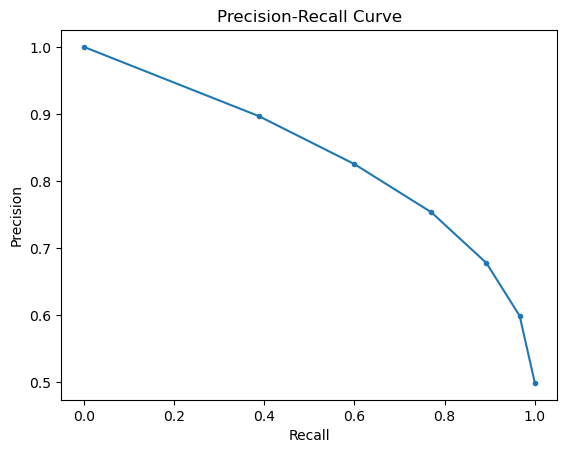

In [18]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_scores = knn_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


In [19]:
# --- DISPLAY PURPOSE ONLY (reporting on TEST) ---
# Assumes: knn_pipeline has been selected via CV on TRAIN and refit on ALL training data.
## refrence: chatgpt 4o

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, confusion_matrix
)
from ipywidgets import interact, FloatSlider

# Scores on TEST
y_scores = knn_pipeline.predict_proba(X_test)[:, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

def show_threshold(threshold=0.50):
    # Binarize at chosen threshold
    y_pred = (y_scores >= threshold).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec_curve, prec_curve, label=f'PR curve (AP={ap:.3f})')
    plt.scatter(r, p, color='red', label=f'@ thr={threshold:.2f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision–Recall (TEST)')
    plt.legend(); plt.grid(True); plt.show()

    # Confusion matrix
    plt.figure(figsize=(4.6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix @ thr={threshold:.2f}'); plt.tight_layout(); plt.show()

interact(show_threshold, threshold=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.50))


interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.99, min=0.01, step=0.01), Output()…

<function __main__.show_threshold(threshold=0.5)>

## 3.2 ROC Curve and AUC

The ROC (Receiver Operating Characteristic) curve is another way to evaluate the performance of a classifier, particularly when dealing with imbalanced datasets. The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (FPR) at different threshold values.

- **Area Under the Curve (AUC)**: The area under the ROC curve. A perfect classifier has an AUC of 1.0, while a random classifier has an AUC of 0.5.

### Why Use ROC AUC?

* Unlike F1, recall, precision and accuracy- AUC is not dependent on a threshold chosen
* This makes it a great metric for measuring a models general performance 💪

### The ROC AUC score ranges from 0 to 1:

- **0.5**: The model performs no better than random guessing.
- **1.0**: The model perfectly distinguishes between the positive and negative classes.
- **Closer to 1**: Indicates better model performance.


ROC AUC — KNN: 0.833 | Logistic: 0.850


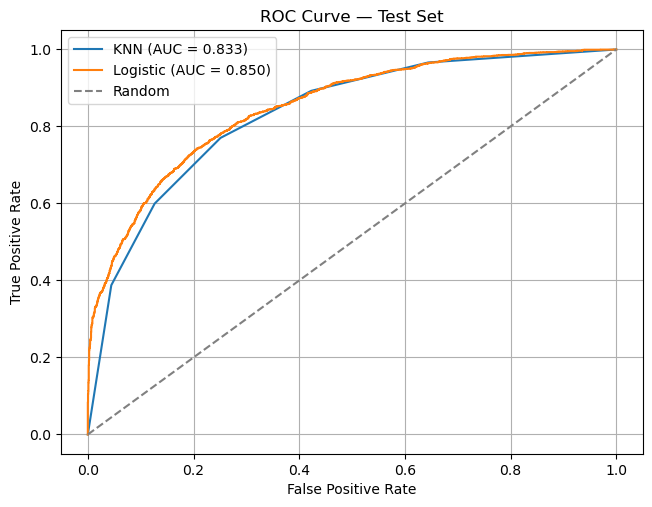

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# 0) Refit chosen models on ALL training data (so test is a final report)
knn_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)

# 1) Get continuous scores on TEST
# If a model lacks predict_proba, use decision_function instead.
y_knn_scores = knn_pipeline.predict_proba(X_test)[:, 1]
y_lr_scores  =  lr_pipeline.predict_proba(X_test)[:, 1]

# 2) AUC numbers (binary y assumed; if labels are strings, encode earlier)
auc_knn = roc_auc_score(y_test, y_knn_scores)
auc_lr  = roc_auc_score(y_test, y_lr_scores)
print(f"ROC AUC — KNN: {auc_knn:.3f} | Logistic: {auc_lr:.3f}")

# 3) ROC curves
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_scores)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_lr_scores)

plt.figure(figsize=(7.5, 5.5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set'); plt.legend(); plt.grid(True); plt.show()


# FAQ: 

<div style="background-color:rgba(75, 0, 130, 0.3); padding:10px;">
**1. Why do I need to use `fit_transform()` on the training data and `transform()` on the test data when preprocessing separately, but not when I add the model to the pipeline?**

When using a model separately, you must manually preprocess the data. You call `fit_transform()` on the training set to learn transformations and `transform()` on the test set to apply the same transformations.

In a pipeline, this is handled automatically. When you call `fit()` on the pipeline, it applies `fit_transform()` on the training data, and during `predict()`, it automatically calls `transform()` on the test data, so no manual transformation of the test set is needed. The pipeline ensures consistency across both training and testing.


**For more see [Extra_transformer Notes](../Dive_deeper/Extra_transformer.ipynb)**
